# Tennis Doubles Homophily — Main Analysis

Data: Grand Slam doubles matches 2018–2025 (excl. 2020). N ≈ 1,795 matches after dropping retirements/walkovers.

Sections:
1. Variable construction
2. Pressure outcomes (tiebreaks, comebacks)
3. Olympic cycle descriptive evidence
4. Baseline regressions — match win / tiebreak win / comeback win

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from getpass import getuser


pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

user = getuser()
df = pd.read_excel(f'C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/men_matches_with_ranks_cleaned.xlsx')
print(f'Loaded {df.shape[0]:,} matches | years: {sorted(df["year"].unique())}')

Loaded 1,840 matches | years: [np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [2]:
# ── Missing data: key regression variables ──────────────────────────────
KEY_VARS = {
    'Country (raw)':       ['winners_p1_country',  'winners_p2_country',
                            'losers_p1_country',   'losers_p2_country'],
    'ISO3 code':           ['winners_p1_iso3',     'winners_p2_iso3',
                            'losers_p1_iso3',      'losers_p2_iso3'],
    'Same country':        ['same_country_winners', 'same_country_losers'],
    'Same language':       ['winners_same_language', 'losers_same_language'],
    'Ling. proximity':     ['winners_linguistic_proximity', 'losers_linguistic_proximity'],
    'Doubles rank':        ['winners_p1_rank_num',  'winners_p2_rank_num',
                            'losers_p1_rank_num',   'losers_p2_rank_num'],
    'GS experience':       ['winners_p1_experience_double', 'winners_p2_experience_double',
                            'losers_p1_experience_double',  'losers_p2_experience_double'],
    'Singles career high': ['winners_p1_singles_career_high_rank_num',
                            'winners_p2_singles_career_high_rank_num',
                            'losers_p1_singles_career_high_rank_num',
                            'losers_p2_singles_career_high_rank_num'],
}

n = len(df)
print(f'Dataset: {n:,} matches\n')
print(f'{"Variable group":<25} {"Cols":<6} {"NaN slots":<12} {"Matches with any NaN"}')
print('-' * 62)
for grp, cols in KEY_VARS.items():
    existing  = [c for c in cols if c in df.columns]
    nan_total = sum(df[c].isna().sum() for c in existing)
    any_nan   = df[existing].isna().any(axis=1).sum()
    print(f'{grp:<25} {len(existing):<6} {nan_total:<12} {any_nan:,}  ({100*any_nan/n:.1f}%)')


Dataset: 1,840 matches

Variable group            Cols   NaN slots    Matches with any NaN
--------------------------------------------------------------
Country (raw)             4      1            1  (0.1%)
ISO3 code                 4      1            1  (0.1%)
Same country              2      1            1  (0.1%)
Same language             2      1            1  (0.1%)
Ling. proximity           2      1            1  (0.1%)
Doubles rank              4      14           14  (0.8%)
GS experience             4      981          651  (35.4%)
Singles career high       4      161          158  (8.6%)


## 1. Variable Construction

In [3]:
# ── Tiebreak flags ────────────────────────────────────────
# Drop likely retirements/walkovers: matches where set scores are missing
# or incomplete, indicating the match did not finish normally.
def regular_set_complete(w, l):
    valid = w.notna() & l.notna()
    hi = pd.concat([w, l], axis=1).max(axis=1)
    lo = pd.concat([w, l], axis=1).min(axis=1)
    return valid & (
        ((hi == 6) & (lo <= 4)) |
        ((hi == 7) & lo.isin([5, 6])) |
        ((hi >= 8) & ((hi - lo) == 2))
    )

def match_tiebreak_complete(w, l):
    valid = w.notna() & l.notna()
    hi = pd.concat([w, l], axis=1).max(axis=1)
    lo = pd.concat([w, l], axis=1).min(axis=1)
    return valid & (hi >= 10) & ((hi - lo) >= 2)

s1_complete = regular_set_complete(df['winners_set1'], df['losers_set1'])
s2_complete = regular_set_complete(df['winners_set2'], df['losers_set2'])
split_sets = (
    ((df['winners_set1'] > df['losers_set1']) & (df['winners_set2'] < df['losers_set2'])) |
    ((df['winners_set1'] < df['losers_set1']) & (df['winners_set2'] > df['losers_set2']))
)
s3_complete = (
    regular_set_complete(df['winners_set3'], df['losers_set3']) |
    match_tiebreak_complete(df['winners_set3'], df['losers_set3'])
)
retired_or_incomplete = ~s1_complete | ~s2_complete | (split_sets & ~s3_complete)
print(f'Dropping likely retirements/walkovers: {retired_or_incomplete.sum():,} matches')

# ── Detail of dropped matches ───────────────────────────────────────
def _classify_drop(row):
    w1, l1 = row.get('winners_set1'), row.get('losers_set1')
    w2, l2 = row.get('winners_set2'), row.get('losers_set2')
    if pd.isna(w1) and pd.isna(l1):
        return 'WALKOVER'
    if pd.notna(w1) and pd.notna(l1) and pd.notna(w2) and pd.notna(l2):
        return 'RETIREMENT-S2+'
    return 'RETIREMENT-S1'

_dropped = df[retired_or_incomplete].copy()
_dropped['drop_reason'] = _dropped.apply(_classify_drop, axis=1)
print(_dropped['drop_reason'].value_counts().to_string())
_show = ['year', 'tournament', 'stage', 'drop_reason',
         'winners_p1_surname', 'winners_p2_surname',
         'losers_p1_surname',  'losers_p2_surname',
         'winners_set1', 'losers_set1',
         'winners_set2', 'losers_set2',
         'winners_set3', 'losers_set3']
_show = [c for c in _show if c in _dropped.columns]
print()
print(_dropped.sort_values('drop_reason')[_show].to_string(index=False))

df = df.loc[~retired_or_incomplete].copy()

# Regular 7-point tiebreak: set reaches 7-6
df['tb_s1'] = ((df['winners_set1']==7)&(df['losers_set1']==6)) | ((df['winners_set1']==6)&(df['losers_set1']==7))
df['tb_s2'] = ((df['winners_set2']==7)&(df['losers_set2']==6)) | ((df['winners_set2']==6)&(df['losers_set2']==7))
df['regular_tb']    = df['tb_s1'] | df['tb_s2']
df['tb_s3_regular'] = (((df['winners_set3']==7)&(df['losers_set3']==6)) | ((df['winners_set3']==6)&(df['losers_set3']==7))).fillna(False)

# Match tiebreak / super-tiebreak (10-point, set3 >= 10)
df['match_tb'] = match_tiebreak_complete(df['winners_set3'], df['losers_set3'])
df['any_tb']   = df['regular_tb'] | df['match_tb'] | df['tb_s3_regular']

# Who won each tiebreak (winner-team perspective)
df['w_won_tb_s1'] = df['tb_s1'] & (df['winners_set1'] == 7)
df['w_won_tb_s2'] = df['tb_s2'] & (df['winners_set2'] == 7)

# ── Match structure ───────────────────────────────────────────
df['three_sets']     = df['winners_set3'].notna()
df['winner_lost_s1'] = df['winners_set1'] < df['losers_set1']
df['comeback']       = df['winner_lost_s1'] & df['three_sets']

# ── Olympic period flags ──────────────────────────────────────
def get_period(row):
    y = row['year']
    t = row['tournament']
    if y in [2018, 2019]:
        return 'Pre-Tokyo'
    elif y == 2020:
        return 'Tokyo Prep' if t != 'Wimbledon' else None
    elif y == 2021:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Tokyo Prep'
        elif t == 'US Open':
            return 'Post-Tokyo'
    elif y == 2022:
        return 'Pre-Paris'
    elif y == 2023:
        return 'Paris Prep'
    elif y == 2024:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Paris Prep'
        elif t == 'US Open':
            return 'Post-Paris'
    elif y == 2025:
        return 'Post-Paris'
    return None

df['cycle'] = df.apply(get_period, axis=1)
df['pre_olympic']    = df['cycle'].isin(['Pre-Paris', 'Paris Prep']).astype(int)
df['olympic_period'] = df['cycle'].isin(['Pre-Paris', 'Paris Prep', 'Post-Paris']).astype(int)
df['olympics_tourn'] = (df['tournament'] == 'Olympics').astype(int)

# ── Match-level homophily differences and averages ───────────────────
df['same_country_diff']  = df['same_country_winners'].astype(float)  - df['same_country_losers'].astype(float)
df['same_language_diff'] = df['winners_same_language'].astype(float) - df['losers_same_language'].astype(float)
df['ling_prox_diff']     = df['winners_linguistic_proximity'].astype(float) - df['losers_linguistic_proximity'].astype(float)

df['same_country_avg']  = (df['same_country_winners'] + df['same_country_losers']) / 2
df['same_language_avg'] = (df['winners_same_language'] + df['losers_same_language']) / 2
df['ling_prox_avg']     = (df['winners_linguistic_proximity'] + df['losers_linguistic_proximity']) / 2
print('Variable construction complete.')


Dropping likely retirements/walkovers: 47 matches
drop_reason
WALKOVER          20
RETIREMENT-S2+    18
RETIREMENT-S1      9

 year      tournament       stage    drop_reason winners_p1_surname winners_p2_surname losers_p1_surname losers_p2_surname  winners_set1  losers_set1  winners_set2  losers_set2  winners_set3  losers_set3
 2023   Roland Garros Round of 32  RETIREMENT-S1                ram          salisbury             baena             munar        3.0000       2.0000           NaN          NaN           NaN          NaN
 2021 Australian Open Round of 64  RETIREMENT-S1               melo              tecau        krajinovic           lajovic        3.0000       0.0000           NaN          NaN           NaN          NaN
 2021       Wimbledon Round of 16  RETIREMENT-S1          göransson               ruud             munar            norrie        4.0000       3.0000           NaN          NaN           NaN          NaN
 2022 Australian Open Round of 64  RETIREMENT-S1          

## 2. Pressure Outcomes - Counts and Inspection

In [4]:
print(f'=== Table 1. Pressure Outcome Counts (all matches, N={len(df):,}) ===')
rows = [
    ('Set-1 tiebreak (7-pt)',                          df['tb_s1']),
    ('Set-2 tiebreak (7-pt)',                          df['tb_s2']),
    ('Set-3 regular tiebreak (7-pt)',                  df['tb_s3_regular']),
    ('Match tiebreak / super-tb (10-pt, set3 â‰¥ 8)',   df['match_tb']),
    ('Any regular tiebreak (sets 1 or 2)',             df['regular_tb']),
    ('Any tiebreak (all types)',                       df['any_tb']),
    ('Match went to 3 sets',                           df['three_sets']),
    ('Comeback wins (winner lost set 1)',               df['comeback']),
]
for lbl, s in rows:
    print(f'  {lbl:<50s}  N={int(s.sum()):4d}  ({100*s.mean():.1f}%)')

print()
print('Regular tiebreaks by tournament:')
print(df.groupby('tournament')['regular_tb'].agg(['sum','mean']).rename(columns={'sum':'N','mean':'Rate'}).round(3).to_string())

print()
print('Match tiebreaks (super-tb) by tournament/year:')
print(df[df['match_tb']].groupby(['tournament','year']).size().to_frame('N').to_string())

print()
print('Comeback wins by tournament:')
print(df.groupby('tournament')['comeback'].agg(['sum','mean']).rename(columns={'sum':'N','mean':'Rate'}).round(3).to_string())

=== Table 1. Pressure Outcome Counts (all matches, N=1,793) ===
  Set-1 tiebreak (7-pt)                               N= 445  (24.8%)
  Set-2 tiebreak (7-pt)                               N= 470  (26.2%)
  Set-3 regular tiebreak (7-pt)                       N= 195  (10.9%)
  Match tiebreak / super-tb (10-pt, set3 â‰¥ 8)       N=  24  (1.3%)
  Any regular tiebreak (sets 1 or 2)                  N= 804  (44.8%)
  Any tiebreak (all types)                            N= 896  (50.0%)
  Match went to 3 sets                                N= 787  (43.9%)
  Comeback wins (winner lost set 1)                   N= 351  (19.6%)

Regular tiebreaks by tournament:
                   N   Rate
tournament                 
Australian Open  197 0.4590
Olympics          28 0.4440
Roland Garros    148 0.3440
US Open          206 0.4760
Wimbledon        225 0.5140

Match tiebreaks (super-tb) by tournament/year:


                  N
tournament year    
Olympics   2021   9
           2024  11
Wimbledon  2018   1
           2021   3

Comeback wins by tournament:
                  N   Rate
tournament                
Australian Open  87 0.2030
Olympics         13 0.2060
Roland Garros    84 0.1950
US Open          84 0.1940
Wimbledon        83 0.1890


### 2.1 Tiebreak types treated together vs separately

Regular tiebreaks (7-point, in sets 1-2) and match tiebreaks (10-point super-tiebreak, set 3) measure the same underlying construct - pressure in a closely contested set - but with different point thresholds. For regression purposes we treat them together as `any_tb`. Match tiebreaks are few (N=30) and concentrated in the Olympics and Wimbledon.

## 3. Olympic Cycle Descriptive Evidence


In [5]:
gs = df[df['olympics_tourn'] == 0].copy()   # Grand Slams only

hcols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']

def assign_tokyo_cycle(row):
    y = row['year']
    t = row['tournament']
    if y in [2018, 2019]:
        return 'Pre-Tokyo'
    if y == 2020:
        return 'Tokyo Prep' if t != 'Wimbledon' else None
    if y == 2021:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Tokyo Prep'
        if t == 'US Open':
            return 'Post-Tokyo'
    if y == 2022:
        return 'Post-Tokyo'
    return None


def assign_paris_cycle(row):
    y = row['year']
    t = row['tournament']

    if y == 2022:
        return 'Pre-Paris'

    if y == 2023:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon', 'US Open']:
            return 'Paris Prep'

    if y == 2024:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Paris Prep'
        if t == 'US Open':
            return 'Post-Paris'

    if y == 2025:
        return 'Post-Paris'

    return None

gs['cycle_tokyo'] = gs.apply(assign_tokyo_cycle, axis=1)
gs['cycle_paris'] = gs.apply(assign_paris_cycle, axis=1)

cycle_order_tokyo = ['Pre-Tokyo', 'Tokyo Prep', 'Post-Tokyo']
cycle_order_paris = ['Pre-Paris', 'Paris Prep', 'Post-Paris']

panel_tokyo = pd.DataFrame({
    'Period': cycle_order_tokyo,
    'Calendar window': ['Jan 2018 - Dec 2019', 'Jan 2020 - Jul 2021', 'Aug 2021 - Dec 2022'],
    'GS included': ['AO18-USO19', 'AO20-Wim21 (ex Wim20)', 'USO21-USO22'],
}).set_index('Period')

panel_paris = pd.DataFrame({
    'Period': cycle_order_paris,
    'Calendar window': ['Jan 2022 - Dec 2022', 'Jan 2023 - Jul 2024', 'Aug 2024 - Dec 2025'],
    'GS included': ['AO22-USO22', 'AO23-Wim24', 'USO24-USO25'],
}).set_index('Period')

by_tokyo = gs[gs['cycle_tokyo'].notna()].groupby('cycle_tokyo')[hcols].mean().reindex(cycle_order_tokyo) * 100
by_tokyo.columns = ['Same Nationality', 'Same Language', 'Ling. Proximity']
by_tokyo['N teams'] = gs[gs['cycle_tokyo'].notna()].groupby('cycle_tokyo').size().reindex(cycle_order_tokyo) * 2

by_paris = gs[gs['cycle_paris'].notna()].groupby('cycle_paris')[hcols].mean().reindex(cycle_order_paris) * 100
by_paris.columns = ['Same Nationality', 'Same Language', 'Ling. Proximity']
by_paris['N teams'] = gs[gs['cycle_paris'].notna()].groupby('cycle_paris').size().reindex(cycle_order_paris) * 2

panel_tokyo = panel_tokyo.join(by_tokyo)
panel_paris = panel_paris.join(by_paris)

print('=== Table 2A. Tokyo 2021 cycle - Same nat/lang/langprox by period ===')
print(panel_tokyo.round({'Same Nationality':1,'Same Language':1,'Ling. Proximity':1}).to_string())

print()
print('=== Table 2B. Paris 2024 cycle - Same nat/lang/langprox by period ===')
print(panel_paris.round({'Same Nationality':1,'Same Language':1,'Ling. Proximity':1}).to_string())

print()
print('Overall same vs. diff homophily rates (Grand Slams, all teams):')
for avg_col, lbl in [
    ('same_country_avg',  'Same nationality'),
    ('same_language_avg', 'Same language'),
    ('ling_prox_avg',     'Ling. proximity'),
]:
    same_pct = 100 * gs[avg_col].mean()
    print(f'  {lbl:<25s}  Same={same_pct:.1f}%  Diff={(100-same_pct):.1f}%')

=== Table 2A. Tokyo 2021 cycle - Same nat/lang/langprox by period ===


                Calendar window            GS included  Same Nationality  Same Language  Ling. Proximity  N teams
Period                                                                                                           
Pre-Tokyo   Jan 2018 - Dec 2019             AO18-USO19           40.1000        54.8000          55.7000     1006
Tokyo Prep  Jan 2020 - Jul 2021  AO20-Wim21 (ex Wim20)           42.0000        56.9000          56.9000      364
Post-Tokyo  Aug 2021 - Dec 2022            USO21-USO22           39.2000        55.0000          55.8000      604

=== Table 2B. Paris 2024 cycle - Same nat/lang/langprox by period ===
                Calendar window  GS included  Same Nationality  Same Language  Ling. Proximity  N teams
Period                                                                                                 
Pre-Paris   Jan 2022 - Dec 2022   AO22-USO22           39.5000        54.3000          55.3000      486
Paris Prep  Jan 2023 - Jul 2024   AO23-Wim24   

In [6]:
# Same vs. diff homophily by year and tournament
avg_cols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']
by_year_tourn = gs.groupby(['year', 'tournament'])[avg_cols].mean() * 100
by_year_tourn.columns = ['Same Nationality (%)', 'Same Language (%)', 'Ling. Proximity (%)']
by_year_tourn['Diff Nationality (%)'] = 100 - by_year_tourn['Same Nationality (%)']
by_year_tourn['Diff Language (%)'] = 100 - by_year_tourn['Same Language (%)']
by_year_tourn['Diff Ling. Proximity (%)'] = 100 - by_year_tourn['Ling. Proximity (%)']
by_year_tourn = by_year_tourn[['Same Nationality (%)', 'Diff Nationality (%)',
                                'Same Language (%)', 'Diff Language (%)',
                                'Ling. Proximity (%)', 'Diff Ling. Proximity (%)']]
print('=== Table 2C. Same vs. Diff homophily by year and tournament (Grand Slams only) ===')
print(by_year_tourn.round(1).to_string())

=== Table 2C. Same vs. Diff homophily by year and tournament (Grand Slams only) ===
                      Same Nationality (%)  Diff Nationality (%)  Same Language (%)  Diff Language (%)  Ling. Proximity (%)  Diff Ling. Proximity (%)
year tournament                                                                                                                                      
2018 Australian Open               38.3000               61.7000            53.3000            46.7000              55.0000                   45.0000
     Roland Garros                 40.5000               59.5000            54.0000            46.0000              57.1000                   42.9000
     US Open                       37.3000               62.7000            51.6000            48.4000              51.6000                   48.4000
     Wimbledon                     30.1000               69.9000            52.7000            47.3000              52.7000                   47.3000
2019 Australian 

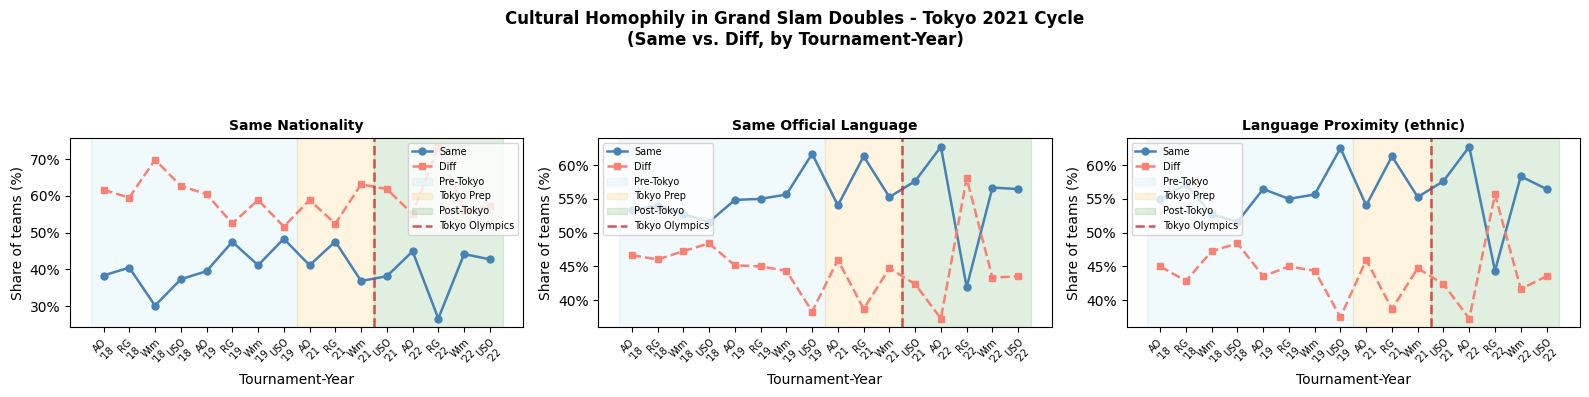

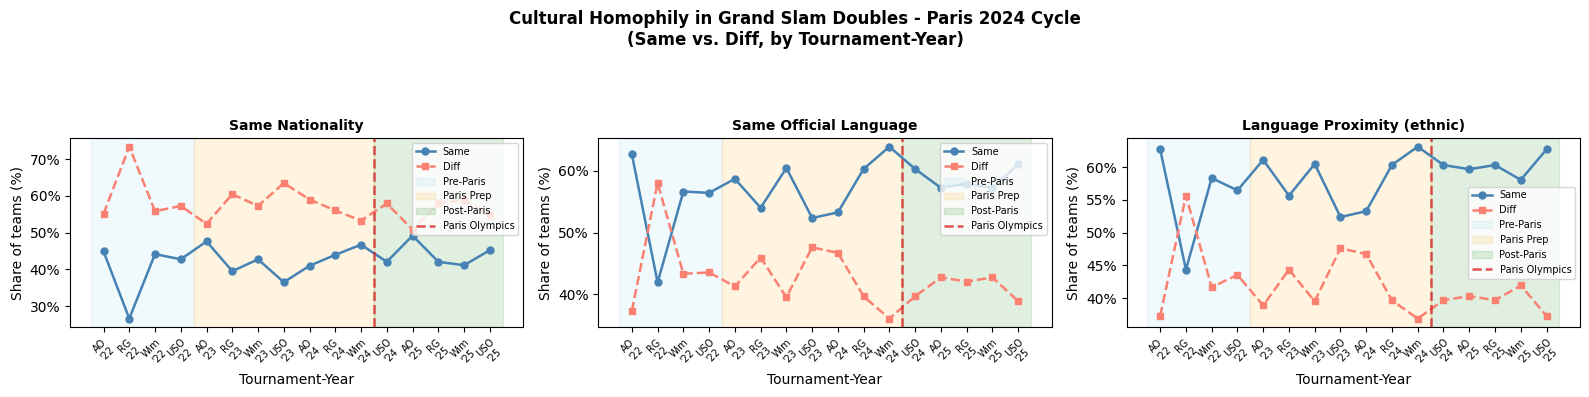

In [7]:
TOURN_ORDER = {'Australian Open': 0, 'Roland Garros': 1, 'Wimbledon': 2, 'US Open': 3}
TOURN_ABBR  = {'Australian Open': 'AO', 'Roland Garros': 'RG', 'Wimbledon': 'Wim', 'US Open': 'USO'}

avg_cols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']
titles   = ['Same Nationality', 'Same Official Language', 'Language Proximity (ethnic)']

# Chronologically-ordered tournament-year means
ty = gs.groupby(['year', 'tournament'])[avg_cols].mean().mul(100).reset_index()
ty['t_order'] = ty['tournament'].map(TOURN_ORDER)
ty = ty.sort_values(['year', 't_order']).reset_index(drop=True)
ty['label'] = ty.apply(lambda r: f"{TOURN_ABBR[r['tournament']]}\n'{str(r['year'])[2:]}", axis=1)

# ── Tokyo cycle ───────────────────────────────────────────────────────────
ty_t = ty[ty['year'].isin([2018, 2019, 2021, 2022])].reset_index(drop=True)
ty_t['x'] = ty_t.index

pre_t  = ty_t['year'].isin([2018, 2019])
prep_t = (ty_t['year'] == 2021) & ty_t['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon'])
post_t = ((ty_t['year'] == 2021) & (ty_t['tournament'] == 'US Open')) | (ty_t['year'] == 2022)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, ac, ttl in zip(axes, avg_cols, titles):
    ax.plot(ty_t['x'], ty_t[ac],       marker='o', color='steelblue', lw=1.8, ms=5, label='Same')
    ax.plot(ty_t['x'], 100-ty_t[ac],   marker='s', color='salmon',    lw=1.8, ms=5, ls='--', label='Diff')
    for mask, color, lbl in [(pre_t, 'skyblue', 'Pre-Tokyo'), (prep_t, 'orange', 'Tokyo Prep'), (post_t, 'green', 'Post-Tokyo')]:
        xs = ty_t.loc[mask, 'x']
        if not xs.empty:
            ax.axvspan(xs.min() - 0.5, xs.max() + 0.5, alpha=0.12, color=color, label=lbl)
    x_wim = ty_t.loc[(ty_t['year'] == 2021) & (ty_t['tournament'] == 'Wimbledon'), 'x']
    x_uso = ty_t.loc[(ty_t['year'] == 2021) & (ty_t['tournament'] == 'US Open'),   'x']
    if not x_wim.empty and not x_uso.empty:
        ax.axvline((x_wim.values[0] + x_uso.values[0]) / 2,
                   color='#d62728', ls='--', lw=1.8, alpha=0.8, label='Tokyo Olympics')
    ax.set_title(ttl, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tournament-Year'); ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(ty_t['x']); ax.set_xticklabels(ty_t['label'], fontsize=7)
    ax.tick_params(axis='x', rotation=45); ax.legend(fontsize=7)

fig.suptitle('Cultural Homophily in Grand Slam Doubles - Tokyo 2021 Cycle\n(Same vs. Diff, by Tournament-Year)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../../ppt/homophily_tokyo_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Paris cycle ───────────────────────────────────────────────────────────
ty_p = ty[ty['year'].isin([2022, 2023, 2024, 2025])].reset_index(drop=True)
ty_p['x'] = ty_p.index

pre_p  = ty_p['year'] == 2022
prep_p = (ty_p['year'] == 2023) | ((ty_p['year'] == 2024) & ty_p['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon']))
post_p = ((ty_p['year'] == 2024) & (ty_p['tournament'] == 'US Open')) | (ty_p['year'] == 2025)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, ac, ttl in zip(axes, avg_cols, titles):
    ax.plot(ty_p['x'], ty_p[ac],       marker='o', color='steelblue', lw=1.8, ms=5, label='Same')
    ax.plot(ty_p['x'], 100-ty_p[ac],   marker='s', color='salmon',    lw=1.8, ms=5, ls='--', label='Diff')
    for mask, color, lbl in [(pre_p, 'skyblue', 'Pre-Paris'), (prep_p, 'orange', 'Paris Prep'), (post_p, 'green', 'Post-Paris')]:
        xs = ty_p.loc[mask, 'x']
        if not xs.empty:
            ax.axvspan(xs.min() - 0.5, xs.max() + 0.5, alpha=0.12, color=color, label=lbl)
    x_wim = ty_p.loc[(ty_p['year'] == 2024) & (ty_p['tournament'] == 'Wimbledon'), 'x']
    x_uso = ty_p.loc[(ty_p['year'] == 2024) & (ty_p['tournament'] == 'US Open'),   'x']
    if not x_wim.empty and not x_uso.empty:
        ax.axvline((x_wim.values[0] + x_uso.values[0]) / 2,
                   color='#d62728', ls='--', lw=1.8, alpha=0.8, label='Paris Olympics')
    ax.set_title(ttl, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tournament-Year'); ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(ty_p['x']); ax.set_xticklabels(ty_p['label'], fontsize=7)
    ax.tick_params(axis='x', rotation=45); ax.legend(fontsize=7)

fig.suptitle('Cultural Homophily in Grand Slam Doubles - Paris 2024 Cycle\n(Same vs. Diff, by Tournament-Year)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../../ppt/homophily_paris_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

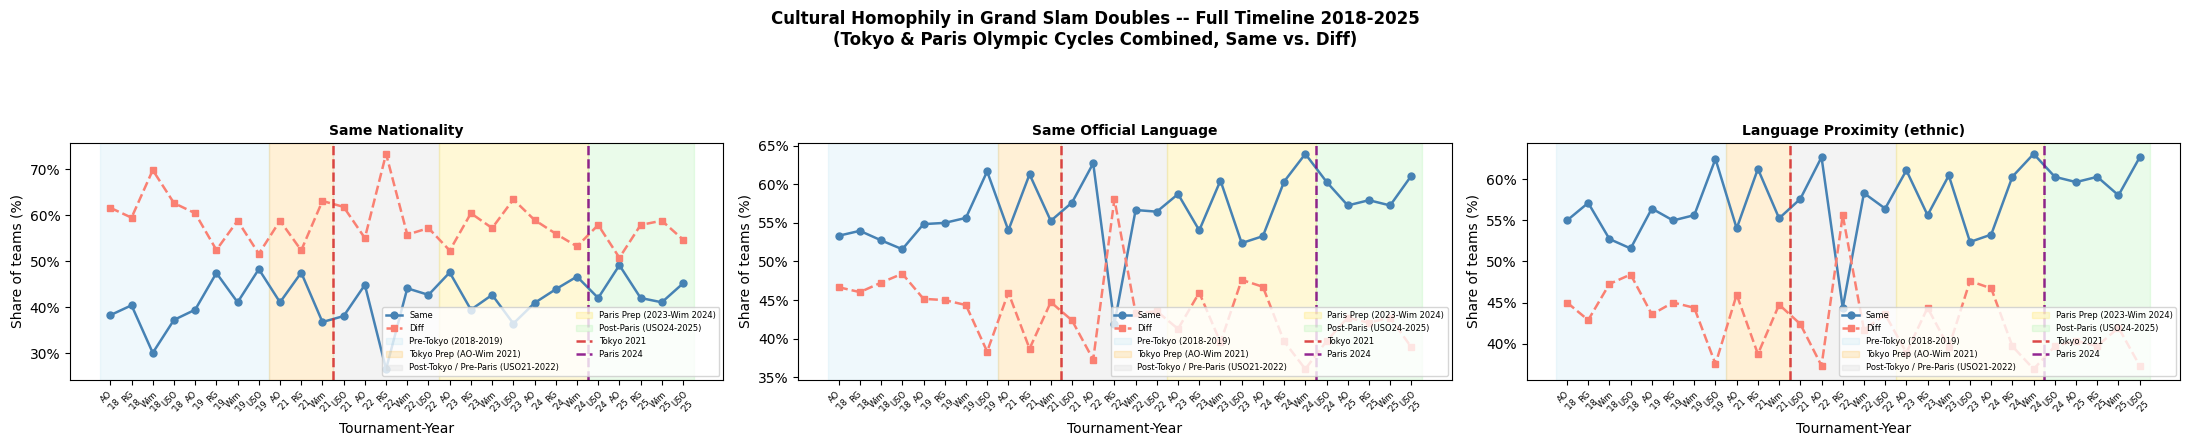

In [8]:
# Combined Tokyo + Paris cycle graph (full timeline 2018-2025)
# Single figure spanning all Grand Slams in the dataset (Olympics excluded).
# Two vertical lines mark the Olympic tournaments; shaded bands show each period.

ty_full = ty.copy()
ty_full['x'] = ty_full.index   # ty already sorted chronologically

mask_pre_tokyo  = ty_full['year'].isin([2018, 2019])
mask_tokyo_prep = (ty_full['year'] == 2021) & ty_full['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon'])
mask_interlude  = ((ty_full['year'] == 2021) & (ty_full['tournament'] == 'US Open')) | (ty_full['year'] == 2022)
mask_paris_prep = (ty_full['year'] == 2023) | ((ty_full['year'] == 2024) & ty_full['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon']))
mask_post_paris = ((ty_full['year'] == 2024) & (ty_full['tournament'] == 'US Open')) | (ty_full['year'] == 2025)

x_wim21 = ty_full.loc[(ty_full['year'] == 2021) & (ty_full['tournament'] == 'Wimbledon'), 'x'].values
x_uso21 = ty_full.loc[(ty_full['year'] == 2021) & (ty_full['tournament'] == 'US Open'),   'x'].values
x_wim24 = ty_full.loc[(ty_full['year'] == 2024) & (ty_full['tournament'] == 'Wimbledon'), 'x'].values
x_uso24 = ty_full.loc[(ty_full['year'] == 2024) & (ty_full['tournament'] == 'US Open'),   'x'].values

fig, axes = plt.subplots(1, 3, figsize=(22, 4.5), sharey=False)
for ax, ac, ttl in zip(axes, avg_cols, titles):
    ax.plot(ty_full['x'], ty_full[ac],       marker='o', color='steelblue', lw=1.8, ms=5, label='Same')
    ax.plot(ty_full['x'], 100 - ty_full[ac], marker='s', color='salmon',    lw=1.8, ms=5, ls='--', label='Diff')

    shades = [
        (mask_pre_tokyo,  'skyblue',    0.13, 'Pre-Tokyo (2018-2019)'),
        (mask_tokyo_prep, 'orange',     0.16, 'Tokyo Prep (AO-Wim 2021)'),
        (mask_interlude,  'lightgray',  0.25, 'Post-Tokyo / Pre-Paris (USO21-2022)'),
        (mask_paris_prep, 'gold',       0.16, 'Paris Prep (2023-Wim 2024)'),
        (mask_post_paris, 'lightgreen', 0.18, 'Post-Paris (USO24-2025)'),
    ]
    for mask, color, alpha, lbl in shades:
        xs = ty_full.loc[mask, 'x']
        if not xs.empty:
            ax.axvspan(xs.min() - 0.5, xs.max() + 0.5, alpha=alpha, color=color, label=lbl)

    if len(x_wim21) and len(x_uso21):
        ax.axvline((x_wim21[0] + x_uso21[0]) / 2, color='#d62728', ls='--', lw=1.8, alpha=0.85, label='Tokyo 2021')
    if len(x_wim24) and len(x_uso24):
        ax.axvline((x_wim24[0] + x_uso24[0]) / 2, color='purple',  ls='--', lw=1.8, alpha=0.85, label='Paris 2024')

    ax.set_title(ttl, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tournament-Year')
    ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(ty_full['x'])
    ax.set_xticklabels(ty_full['label'], fontsize=6)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=6, ncol=2, loc='lower right')

fig.suptitle('Cultural Homophily in Grand Slam Doubles -- Full Timeline 2018-2025\n'
             '(Tokyo & Paris Olympic Cycles Combined, Same vs. Diff)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../../ppt/homophily_combined_cycles.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Team Panel Construction

Convert match-level data to team-level panel: each match creates 2 observations (winners=1, losers=0).


In [9]:
# Build team panel (match-level to team-level: winners row + losers row)
match_vars = ['match_id','tournament','year','surface','stage_code','any_tb','regular_tb','match_tb','tb_s3_regular',
              'three_sets','comeback','winner_lost_s1','pre_olympic','olympic_period','olympics_tourn']

# Winners row
w_row = df[match_vars].copy()
for col, src in [('same_country','same_country_winners'),('same_language','winners_same_language'),
                 ('ling_prox','winners_linguistic_proximity'),('rank_mean','rank_mean_winners'),
                 ('wl_career_diff','wl_career_diff_winners'),('rank_gap','rank_diff_winners')]:
    w_row[col] = df[src].values
w_row['single_top100'] = ((df['winners_p1_top100_within_1y']==1) | (df['winners_p2_top100_within_1y']==1)).astype(int)
w_row['win'] = 1
w_row['won_tb_s1'] = df['w_won_tb_s1'].values
w_row['won_tb_s2'] = df['w_won_tb_s2'].values

# Losers row
l_row = df[match_vars].copy()
for col, src in [('same_country','same_country_losers'),('same_language','losers_same_language'),
                 ('ling_prox','losers_linguistic_proximity'),('rank_mean','rank_mean_losers'),
                 ('wl_career_diff','wl_career_diff_losers'),('rank_gap','rank_diff_losers')]:
    l_row[col] = df[src].values
l_row['single_top100'] = ((df['losers_p1_top100_within_1y']==1) | (df['losers_p2_top100_within_1y']==1)).astype(int)
l_row['win'] = 0
l_row['won_tb_s1'] = (df['tb_s1'] & (df['winners_set1']==6)).values
l_row['won_tb_s2'] = (df['tb_s2'] & (df['winners_set2']==6)).values

# Team-level experience: avg GS doubles appearances across both players (values <=0 treated as NaN)
for _row, _p1c, _p2c in [
    (w_row, 'winners_p1_experience_double', 'winners_p2_experience_double'),
    (l_row, 'losers_p1_experience_double',  'losers_p2_experience_double'),
]:
    _e1 = df[_p1c].where(df[_p1c] > 0).values.astype(float)
    _e2 = df[_p2c].where(df[_p2c] > 0).values.astype(float)
    with np.errstate(all='ignore'):
        _exp = np.nanmean(np.column_stack([_e1, _e2]), axis=1)
    _exp[np.isnan(_e1) & np.isnan(_e2)] = np.nan
    _row['exp_mean'] = _exp

# Concatenate and compute derived variables
team_df = pd.concat([w_row, l_row], ignore_index=True)
team_df['opp_rank_mean'] = team_df.groupby('match_id')['rank_mean'].transform('sum') - team_df['rank_mean']
team_df['stage_code'] = team_df['stage_code'].fillna(-1).astype(int)
team_df['lost_set1'] = np.where(team_df['win']==1, team_df['winner_lost_s1'], ~team_df['winner_lost_s1'])
team_df['comeback'] = (team_df['win'] & team_df['lost_set1']).astype(int)

# Convert booleans to int
for col in team_df.columns:
    if str(team_df[col].dtype) in ('bool','boolean','Int64','Int32'):
        team_df[col] = team_df[col].fillna(0).astype(int)

# Drop entire matches with incomplete ranking or nationality data
bad_rank = set(team_df.loc[team_df['rank_mean'].isna(), 'match_id'])
bad_nat  = set(
    team_df.loc[team_df[['same_country','same_language','ling_prox']].isna().any(axis=1), 'match_id']
)
bad_matches = bad_rank | bad_nat
n_rank = len(bad_rank)
n_nat  = len(bad_nat - bad_rank)

team_df = team_df[~team_df['match_id'].isin(bad_matches)].reset_index(drop=True)

print(f'Team panel constructed: {len(team_df):,} obs | {team_df["match_id"].nunique():,} matches')
print(f'  Dropped {n_rank} matches: ranking incomplete (both players on one team unranked)')
print(f'  Dropped {n_nat} matches: nationality/language data missing for at least one player')
print(f'  Total matches dropped: {len(bad_matches)}')
print(f'  exp_mean coverage: {team_df["exp_mean"].notna().sum():,} / {len(team_df):,} obs ({100*team_df["exp_mean"].notna().mean():.1f}%)')


Team panel constructed: 3,558 obs | 1,779 matches
  Dropped 14 matches: ranking incomplete (both players on one team unranked)
  Dropped 0 matches: nationality/language data missing for at least one player
  Total matches dropped: 14
  exp_mean coverage: 3,345 / 3,558 obs (94.0%)


## 4. Baseline Regressions

Each match contributes **two** observations (winner team = 1, loser team = 0).  
Each culture measure (`same_country`, `same_language`, `ling_prox`) is entered one at a time.  
Controls: team average doubles ranking, opponent ranking, teammate rank gap, top-100 singles indicator.  
Fixed effects: tournament-by-year interaction, round (stage_code).  
Standard errors clustered by match.

In [10]:
# Grand Slams panel (Olympics excluded)
# Cell 14 already dropped incomplete-ranking and incomplete-nationality matches from team_df
team_gs = team_df[team_df['olympics_tourn'] == 0].dropna(subset=['rank_mean', 'rank_gap']).copy()
team_gs['won_regular_tb'] = ((team_gs['won_tb_s1'] == 1) | (team_gs['won_tb_s2'] == 1)).astype(int)
team_gs['won_any_tb'] = ((team_gs['won_tb_s1'] == 1) | (team_gs['won_tb_s2'] == 1) |
                         (team_gs['match_tb'] == 1) | (team_gs['tb_s3_regular'] == 1)).astype(int)

team_gs['exp_mean_sq'] = team_gs['exp_mean'] ** 2
gs_matches = team_gs['match_id'].nunique()
mc = team_gs.groupby('match_id').size()
print(f'Team panel (Grand Slams only): {len(team_gs):,} obs | {gs_matches:,} unique matches')
print(f'  Complete pairs (2 obs): {(mc==2).sum():,}  |  Singleton obs (rank or nat/lang incomplete): {(mc==1).sum():,}')

# Panel including Olympics
team_all = team_df.dropna(subset=['rank_mean', 'rank_gap']).copy()
team_all['won_regular_tb'] = ((team_all['won_tb_s1'] == 1) | (team_all['won_tb_s2'] == 1)).astype(int)
team_all['won_any_tb'] = ((team_all['won_tb_s1'] == 1) | (team_all['won_tb_s2'] == 1) |
                          (team_all['match_tb'] == 1) | (team_all['tb_s3_regular'] == 1)).astype(int)
team_all['exp_mean_sq'] = team_all['exp_mean'] ** 2
print(f'Team panel (incl. Olympics):   {len(team_all):,} obs | {team_all["match_id"].nunique():,} unique matches')

Team panel (Grand Slams only): 3,432 obs | 1,716 unique matches
  Complete pairs (2 obs): 1,716  |  Singleton obs (rank or nat/lang incomplete): 0
Team panel (incl. Olympics):   3,558 obs | 1,779 unique matches


In [11]:
output_gs  = f'C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/team_gs_panel.csv'
output_all = f'C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/team_all_panel.csv'
team_gs.to_csv(output_gs,  index=False)
team_all.to_csv(output_all, index=False)
print(f'Grand Slams panel saved to {output_gs}')
print(f'Full panel (incl. Olympics) saved to {output_all}')

Grand Slams panel saved to C:/Users/aldi/Documents/GitHub/tennis-homophily/data/atp/team_gs_panel.csv
Full panel (incl. Olympics) saved to C:/Users/aldi/Documents/GitHub/tennis-homophily/data/atp/team_all_panel.csv


In [12]:
FE = '+ C(tournament):C(year) + C(stage_code)'

CULTURE_VARS = [
    ('same_country',  'Same nationality'),
    ('same_language', 'Same official language'),
    ('ling_prox',     'Language proximity (ethnic)'),
]

CONTROLS = 'rank_mean + opp_rank_mean + single_top100 + exp_mean + exp_mean_sq'

ctrl_vars = [
    ('rank_mean',      'Team avg doubles ranking'),
    ('opp_rank_mean',  'Opponent avg doubles ranking'),
    ('single_top100',  'Top-100 singles player'),
    ('exp_mean',       'Team avg GS appearances'),
    ('exp_mean_sq',    'GS experience squared'),
]
CONTROLS_RG = CONTROLS + ' + rank_gap'
rg_ctrl_vars = ctrl_vars + [('rank_gap', 'Teammate rank gap')]

def show_vars(res, var_list, prefix=''):
    for v, lbl in var_list:
        if v not in res.params:
            continue
        c, se, p = res.params[v], res.bse[v], res.pvalues[v]
        stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
        print(f'  {prefix}{lbl:<42s}  {c:+.4f}{stars:<3s}  se={se:.4f}  p={p:.3f}')

In [13]:
print('=== Table 3. Match Win -- Logit ===')
print('FE: tournament x year + round | SE clustered by match | Sample: Grand Slams only')
gs_exp_n = team_gs['exp_mean'].notna().sum()
print(f'\nN with experience data: {gs_exp_n:,} / {len(team_gs):,} obs ({100*gs_exp_n/len(team_gs):.1f}%)')
print('Sample means \u2014 rank_mean | opp_rank_mean | exp_mean:')
for _lbl, _sub in [('  Winners (win=1)', team_gs[team_gs['win']==1]),
                   ('  Losers  (win=0)', team_gs[team_gs['win']==0]),
                   ('  Combined        ', team_gs)]:
    print(f'{_lbl}: {_sub["rank_mean"].mean():.1f} | {_sub["opp_rank_mean"].mean():.1f} | {_sub["exp_mean"].mean():.1f}')

_gs = team_gs.dropna(subset=['exp_mean'])
for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'win ~ {cvar} + {CONTROLS} {FE}', data=_gs).fit(
        cov_type='cluster', cov_kwds={'groups': _gs['match_id']}, disp=False)
    print(f'\n  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_vars(res, [(cvar, clbl)] + ctrl_vars)


=== Table 3. Match Win -- Logit ===
FE: tournament x year + round | SE clustered by match | Sample: Grand Slams only

N with experience data: 3,222 / 3,432 obs (93.9%)
Sample means — rank_mean | opp_rank_mean | exp_mean:
  Winners (win=1): 84.2 | 172.9 | 13.2
  Losers  (win=0): 172.9 | 84.2 | 12.0
  Combined        : 128.6 | 128.6 | 12.6



  [Same nationality]  N=3,222  Pseudo-R2=0.096
  Same nationality                            +0.1596**   se=0.0808  p=0.048
  Team avg doubles ranking                    -0.0034***  se=0.0004  p=0.000
  Opponent avg doubles ranking                +0.0033***  se=0.0003  p=0.000
  Top-100 singles player                      -0.0048     se=0.1507  p=0.975
  Team avg GS appearances                     +0.1039**   se=0.0416  p=0.013
  GS experience squared                       -0.0033**   se=0.0015  p=0.028

  [Same official language]  N=3,222  Pseudo-R2=0.097
  Same official language                      +0.2060***  se=0.0776  p=0.008
  Team avg doubles ranking                    -0.0033***  se=0.0004  p=0.000
  Opponent avg doubles ranking                +0.0033***  se=0.0003  p=0.000
  Top-100 singles player                      +0.0022     se=0.1508  p=0.988
  Team avg GS appearances                     +0.1050**   se=0.0414  p=0.011
  GS experience squared                       -0.00


  [Language proximity (ethnic)]  N=3,222  Pseudo-R2=0.097
  Language proximity (ethnic)                 +0.1885**   se=0.0775  p=0.015
  Team avg doubles ranking                    -0.0033***  se=0.0004  p=0.000
  Opponent avg doubles ranking                +0.0033***  se=0.0003  p=0.000
  Top-100 singles player                      +0.0048     se=0.1507  p=0.975
  Team avg GS appearances                     +0.1030**   se=0.0414  p=0.013
  GS experience squared                       -0.0033**   se=0.0015  p=0.028


In [14]:
print('=== Table 3b. Sensitivity: With Teammate Rank Gap -- Logit ===')
print('Same sample as Table 3. Shows homophily coefficients are stable when rank gap is added.')
print('FE: tournament x year + round | SE clustered by match | Sample: Grand Slams only')

_gs = team_gs.dropna(subset=['exp_mean'])
for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'win ~ {cvar} + {CONTROLS_RG} {FE}', data=_gs).fit(
        cov_type='cluster', cov_kwds={'groups': _gs['match_id']}, disp=False)
    print(f'\n  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_vars(res, [(cvar, clbl)] + rg_ctrl_vars)


=== Table 3b. Sensitivity: With Teammate Rank Gap -- Logit ===
Same sample as Table 3. Shows homophily coefficients are stable when rank gap is added.
FE: tournament x year + round | SE clustered by match | Sample: Grand Slams only



  [Same nationality]  N=3,222  Pseudo-R2=0.097
  Same nationality                            +0.1578*    se=0.0808  p=0.051
  Team avg doubles ranking                    -0.0041***  se=0.0007  p=0.000
  Opponent avg doubles ranking                +0.0033***  se=0.0003  p=0.000
  Top-100 singles player                      +0.0101     se=0.1510  p=0.946
  Team avg GS appearances                     +0.0958**   se=0.0422  p=0.023
  GS experience squared                       -0.0031**   se=0.0015  p=0.043
  Teammate rank gap                           +0.0007     se=0.0005  p=0.152

  [Same official language]  N=3,222  Pseudo-R2=0.098
  Same official language                      +0.2031***  se=0.0776  p=0.009
  Team avg doubles ranking                    -0.0040***  se=0.0007  p=0.000
  Opponent avg doubles ranking                +0.0033***  se=0.0003  p=0.000
  Top-100 singles player                      +0.0167     se=0.1512  p=0.912
  Team avg GS appearances                     +0.09


  [Language proximity (ethnic)]  N=3,222  Pseudo-R2=0.097
  Language proximity (ethnic)                 +0.1851**   se=0.0775  p=0.017
  Team avg doubles ranking                    -0.0040***  se=0.0007  p=0.000
  Opponent avg doubles ranking                +0.0033***  se=0.0003  p=0.000
  Top-100 singles player                      +0.0193     se=0.1511  p=0.899
  Team avg GS appearances                     +0.0949**   se=0.0419  p=0.024
  GS experience squared                       -0.0031**   se=0.0015  p=0.043
  Teammate rank gap                           +0.0007     se=0.0005  p=0.162


In [15]:
print('=== Table 4. Match Win in Tiebreak Matches -- Logit ===')
print('Sample: GS matches with any tiebreak (7-pt set 1/2 or 10-pt match-TB)')
print('Outcome: match win (win=1 winner team, win=0 loser team)')
print('FE: tournament x year + round | SE clustered by match')

tb_any = team_gs[team_gs['any_tb'] == 1].copy()
tb_any_matches = tb_any['match_id'].nunique()
print(f'\nN={len(tb_any):,} team-obs | {tb_any_matches:,} matches')
print('  Sample means \u2014 rank_mean | opp_rank_mean | rank_gap:')
for _lbl, _sub in [('    Match winners (win=1)', tb_any[tb_any['win']==1]),
                   ('    Match losers  (win=0)', tb_any[tb_any['win']==0]),
                   ('    Combined              ', tb_any)]:
    print(f'{_lbl}: {_sub["rank_mean"].mean():.1f} | {_sub["opp_rank_mean"].mean():.1f} | {_sub["rank_gap"].mean():.1f}')

_tb = tb_any.dropna(subset=['exp_mean'])
for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'win ~ {cvar} + {CONTROLS} {FE}', data=_tb).fit(
        cov_type='cluster', cov_kwds={'groups': _tb['match_id']}, disp=False)
    print(f'\n  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_vars(res, [(cvar, clbl)] + ctrl_vars)


=== Table 4. Match Win in Tiebreak Matches -- Logit ===
Sample: GS matches with any tiebreak (7-pt set 1/2 or 10-pt match-TB)
Outcome: match win (win=1 winner team, win=0 loser team)
FE: tournament x year + round | SE clustered by match



N=1,714 team-obs | 857 matches
  Sample means — rank_mean | opp_rank_mean | rank_gap:
    Match winners (win=1): 83.5 | 135.1 | 50.8
    Match losers  (win=0): 135.1 | 83.5 | 96.2
    Combined              : 109.3 | 109.3 | 73.5

  [Same nationality]  N=1,596  Pseudo-R2=0.045
  Same nationality                            +0.1949*    se=0.1156  p=0.092
  Team avg doubles ranking                    -0.0026***  se=0.0005  p=0.000
  Opponent avg doubles ranking                +0.0021***  se=0.0004  p=0.000
  Top-100 singles player                      +0.3287     se=0.2167  p=0.129
  Team avg GS appearances                     +0.0640     se=0.0573  p=0.264
  GS experience squared                       -0.0017     se=0.0021  p=0.422

  [Same official language]  N=1,596  Pseudo-R2=0.045
  Same official language                      +0.2082*    se=0.1090  p=0.056
  Team avg doubles ranking                    -0.0026***  se=0.0005  p=0.000
  Opponent avg doubles ranking                +0.002

In [16]:
print('=== Table 4b. Sensitivity: Tiebreak Sample, With Rank Gap -- Logit ===')
print('Same sample as Table 4. Shows stability when teammate rank gap is added.')

_tb = tb_any.dropna(subset=['exp_mean'])
for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'win ~ {cvar} + {CONTROLS_RG} {FE}', data=_tb).fit(
        cov_type='cluster', cov_kwds={'groups': _tb['match_id']}, disp=False)
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_vars(res, [(cvar, clbl)] + rg_ctrl_vars)


=== Table 4b. Sensitivity: Tiebreak Sample, With Rank Gap -- Logit ===
Same sample as Table 4. Shows stability when teammate rank gap is added.


  [Same nationality]  N=1,596  Pseudo-R2=0.045
  Same nationality                            +0.1950*    se=0.1157  p=0.092
  Team avg doubles ranking                    -0.0026***  se=0.0008  p=0.002
  Opponent avg doubles ranking                +0.0021***  se=0.0004  p=0.000
  Top-100 singles player                      +0.3277     se=0.2160  p=0.129
  Team avg GS appearances                     +0.0647     se=0.0580  p=0.265
  GS experience squared                       -0.0017     se=0.0021  p=0.421
  Teammate rank gap                           -0.0001     se=0.0006  p=0.928
  [Same official language]  N=1,596  Pseudo-R2=0.045
  Same official language                      +0.2083*    se=0.1091  p=0.056
  Team avg doubles ranking                    -0.0026***  se=0.0008  p=0.002
  Opponent avg doubles ranking                +0.0021***  se=0.0004  p=0.000
  Top-100 singles player                      +0.3367     se=0.2163  p=0.119
  Team avg GS appearances                     +0.0647

In [17]:
print('=== Table 4c. Match Win, Last-Set Tiebreak Only -- Logit ===')
print('Sample: GS matches decided by a last-set tiebreak (set-3 regular 7-pt or 10-pt match TB).')
print('Outcome: match win. FE: tournament x year + round | SE clustered by match')

tb_last = team_gs[(team_gs['tb_s3_regular']==1) | (team_gs['match_tb']==1)].copy()
tb_last_matches = tb_last['match_id'].nunique()
print(f'N={len(tb_last):,} team-obs | {tb_last_matches:,} matches')
print(f'  (any-TB Table 4: {len(tb_any):,} obs | {tb_any["match_id"].nunique():,} matches)')

_tbl = tb_last.dropna(subset=['exp_mean'])
for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'win ~ {cvar} + {CONTROLS} {FE}', data=_tbl).fit(
        cov_type='cluster', cov_kwds={'groups': _tbl['match_id']}, disp=False)
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_vars(res, [(cvar, clbl)] + ctrl_vars)
    print()


=== Table 4c. Match Win, Last-Set Tiebreak Only -- Logit ===
Sample: GS matches decided by a last-set tiebreak (set-3 regular 7-pt or 10-pt match TB).
Outcome: match win. FE: tournament x year + round | SE clustered by match
N=398 team-obs | 199 matches
  (any-TB Table 4: 1,714 obs | 857 matches)


  [Same nationality]  N=371  Pseudo-R2=0.039
  Same nationality                            +0.1458     se=0.2600  p=0.575
  Team avg doubles ranking                    -0.0021**   se=0.0010  p=0.030
  Opponent avg doubles ranking                +0.0013     se=0.0008  p=0.127
  Top-100 singles player                      +1.1769**   se=0.5367  p=0.028
  Team avg GS appearances                     -0.1978     se=0.1237  p=0.110
  GS experience squared                       +0.0089*    se=0.0047  p=0.057



  [Same official language]  N=371  Pseudo-R2=0.039
  Same official language                      +0.0850     se=0.2412  p=0.724
  Team avg doubles ranking                    -0.0021**   se=0.0010  p=0.030
  Opponent avg doubles ranking                +0.0013     se=0.0008  p=0.133
  Top-100 singles player                      +1.1810**   se=0.5354  p=0.027
  Team avg GS appearances                     -0.2029*    se=0.1231  p=0.099
  GS experience squared                       +0.0090*    se=0.0046  p=0.051

  [Language proximity (ethnic)]  N=371  Pseudo-R2=0.039
  Language proximity (ethnic)                 +0.0609     se=0.2405  p=0.800
  Team avg doubles ranking                    -0.0021**   se=0.0010  p=0.031
  Opponent avg doubles ranking                +0.0013     se=0.0008  p=0.134
  Top-100 singles player                      +1.1801**   se=0.5352  p=0.027
  Team avg GS appearances                     -0.2031*    se=0.1230  p=0.099
  GS experience squared                      

C:\Users\aldi\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\aldi\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\aldi\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [18]:
print('=== Table 4d. Match Win, 7-Point Tiebreaks Only -- Logit ===')
print('Sample: GS matches with a regular 7-pt tiebreak in set 1 or set 2 (excludes 10-pt match TB).')
print('Outcome: match win. FE: tournament x year + round | SE clustered by match')

tb_7pt = team_gs[team_gs['regular_tb'] == 1].copy()  # regular_tb = 7-pt TB in set 1 or 2
tb_7pt_matches = tb_7pt['match_id'].nunique()
print(f'N={len(tb_7pt):,} team-obs | {tb_7pt_matches:,} matches')
print(f'  (any-TB Table 4: {len(tb_any):,} obs | {tb_any["match_id"].nunique():,} matches)')

_tb7 = tb_7pt.dropna(subset=['exp_mean'])
for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'win ~ {cvar} + {CONTROLS} {FE}', data=_tb7).fit(
        cov_type='cluster', cov_kwds={'groups': _tb7['match_id']}, disp=False)
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_vars(res, [(cvar, clbl)] + ctrl_vars)
    print()


=== Table 4d. Match Win, 7-Point Tiebreaks Only -- Logit ===
Sample: GS matches with a regular 7-pt tiebreak in set 1 or set 2 (excludes 10-pt match TB).
Outcome: match win. FE: tournament x year + round | SE clustered by match
N=1,540 team-obs | 770 matches
  (any-TB Table 4: 1,714 obs | 857 matches)


  [Same nationality]  N=1,435  Pseudo-R2=0.051
  Same nationality                            +0.1952     se=0.1245  p=0.117
  Team avg doubles ranking                    -0.0029***  se=0.0006  p=0.000
  Opponent avg doubles ranking                +0.0024***  se=0.0005  p=0.000
  Top-100 singles player                      +0.2078     se=0.2308  p=0.368
  Team avg GS appearances                     +0.0744     se=0.0616  p=0.227
  GS experience squared                       -0.0021     se=0.0023  p=0.361



  [Same official language]  N=1,435  Pseudo-R2=0.051
  Same official language                      +0.1905     se=0.1173  p=0.104
  Team avg doubles ranking                    -0.0028***  se=0.0006  p=0.000
  Opponent avg doubles ranking                +0.0024***  se=0.0005  p=0.000
  Top-100 singles player                      +0.2199     se=0.2312  p=0.342
  Team avg GS appearances                     +0.0743     se=0.0613  p=0.225
  GS experience squared                       -0.0021     se=0.0022  p=0.350



  [Language proximity (ethnic)]  N=1,435  Pseudo-R2=0.051
  Language proximity (ethnic)                 +0.1845     se=0.1170  p=0.115
  Team avg doubles ranking                    -0.0028***  se=0.0006  p=0.000
  Opponent avg doubles ranking                +0.0024***  se=0.0005  p=0.000
  Top-100 singles player                      +0.2215     se=0.2311  p=0.338
  Team avg GS appearances                     +0.0728     se=0.0613  p=0.235
  GS experience squared                       -0.0020     se=0.0022  p=0.364



In [19]:
print('=== Table 5. Comeback Win (Adversity Sample) -- Logit ===')
print('Sample: all GS teams that lost set 1.')
print('Each match contributes ONE observation (the team that lost set 1).')
print('Outcome: win=1 (comeback) or win=0 (any loss).')
print('FE: tournament x year + round | SE: HC3 robust')

cb_adv = team_gs[team_gs['lost_set1'] == 1].copy()

n_win  = cb_adv['win'].sum()
n_3s_l = ((cb_adv['three_sets'] == 1) & (cb_adv['win'] == 0)).sum()
n_2s_l = ((cb_adv['three_sets'] == 0) & (cb_adv['win'] == 0)).sum()
print(f'\nAdversity obs: {len(cb_adv):,}  (= {cb_adv["match_id"].nunique():,} matches)')
print(f'  comeback wins:       {n_win:,}  ({100*n_win/len(cb_adv):.1f}%)')
print(f'  3-set losses:        {n_3s_l:,}  ({100*n_3s_l/len(cb_adv):.1f}%)')
print(f'  straight-set losses: {n_2s_l:,}  ({100*n_2s_l/len(cb_adv):.1f}%)')
print('  Sample means \u2014 rank_mean | opp_rank_mean | rank_gap:')
for _lbl, _sub in [('    Comeback wins (win=1)', cb_adv[cb_adv['win']==1]),
                   ('    Other losses  (win=0)', cb_adv[cb_adv['win']==0]),
                   ('    Combined              ', cb_adv)]:
    print(f'{_lbl}: {_sub["rank_mean"].mean():.1f} | {_sub["opp_rank_mean"].mean():.1f} | {_sub["rank_gap"].mean():.1f}')

cb_adv['ty'] = cb_adv['tournament'].astype(str) + '__' + cb_adv['year'].astype(int).astype(str)
_ty_ok = cb_adv.groupby('ty')['win'].nunique()
cb_adv = cb_adv[cb_adv['ty'].isin(_ty_ok[_ty_ok == 2].index)].copy()
print(f'After dropping non-informative ty cells: N={len(cb_adv):,}')

for cvar, clbl in CULTURE_VARS:
    for fe_try, label in [
        ('+ C(ty) + C(stage_code)', 'ty FE + stage FE'),
        ('+ C(ty)', 'ty FE only'),
    ]:
        try:
            res = smf.logit(f'win ~ {cvar} + {CONTROLS} {fe_try}', data=cb_adv).fit(
                cov_type='HC3', disp=False, maxiter=200)
            print(f'\n  [{clbl}]  FE: {label}  |  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
            show_vars(res, [(cvar, clbl)] + ctrl_vars)
            break
        except Exception as e:
            print(f'  [{clbl}] {label} failed: {e}')


=== Table 5. Comeback Win (Adversity Sample) -- Logit ===
Sample: all GS teams that lost set 1.
Each match contributes ONE observation (the team that lost set 1).
Outcome: win=1 (comeback) or win=0 (any loss).
FE: tournament x year + round | SE: HC3 robust

Adversity obs: 1,716  (= 1,716 matches)
  comeback wins:       334  (19.5%)
  3-set losses:        428  (24.9%)
  straight-set losses: 954  (55.6%)
  Sample means — rank_mean | opp_rank_mean | rank_gap:
    Comeback wins (win=1): 101.5 | 120.4 | 65.8
    Other losses  (win=0): 185.6 | 80.0 | 134.6
    Combined              : 169.3 | 87.9 | 121.2
After dropping non-informative ty cells: N=1,716



  [Same nationality]  FE: ty FE + stage FE  |  N=1,592  Pseudo-R2=0.061
  Same nationality                            -0.1558     se=0.1384  p=0.260
  Team avg doubles ranking                    -0.0025***  se=0.0006  p=0.000
  Opponent avg doubles ranking                +0.0019***  se=0.0004  p=0.000
  Top-100 singles player                      -0.2584     se=0.2547  p=0.310
  Team avg GS appearances                     -0.0115     se=0.0655  p=0.861
  GS experience squared                       +0.0007     se=0.0024  p=0.784


C:\Users\aldi\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



  [Same official language]  FE: ty FE + stage FE  |  N=1,592  Pseudo-R2=0.062
  Same official language                      -0.2258*    se=0.1332  p=0.090
  Team avg doubles ranking                    -0.0026***  se=0.0006  p=0.000
  Opponent avg doubles ranking                +0.0019***  se=0.0004  p=0.000
  Top-100 singles player                      -0.2617     se=0.2543  p=0.304
  Team avg GS appearances                     -0.0130     se=0.0652  p=0.842
  GS experience squared                       +0.0007     se=0.0024  p=0.770



  [Language proximity (ethnic)]  FE: ty FE + stage FE  |  N=1,592  Pseudo-R2=0.062
  Language proximity (ethnic)                 -0.2214*    se=0.1332  p=0.096
  Team avg doubles ranking                    -0.0026***  se=0.0006  p=0.000
  Opponent avg doubles ranking                +0.0019***  se=0.0004  p=0.000
  Top-100 singles player                      -0.2656     se=0.2542  p=0.296
  Team avg GS appearances                     -0.0114     se=0.0652  p=0.862
  GS experience squared                       +0.0006     se=0.0024  p=0.789


C:\Users\aldi\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
# Adversity sample breakdown: compare mean ranks for 0|1|1, 0|1|0, and 0|0 groups
# 0|1|1 = lost set 1, won set 2, won set 3 (comeback win)
# 0|1|0 = lost set 1, won set 2, lost set 3 (three-set loss)
# 0|0   = lost set 1, lost set 2 (straight-set loss)

cb_all = team_gs[team_gs['lost_set1'] == 1].copy()
grp_011 = cb_all[(cb_all['win'] == 1)]
grp_010 = cb_all[(cb_all['win'] == 0) & (cb_all['three_sets'] == 1)]
grp_00  = cb_all[(cb_all['win'] == 0) & (cb_all['three_sets'] == 0)]

print('Adversity sample: mean ranks by outcome group')
print(f'  {"Group":<28} {"N":>5} {"rank_mean":>10} {"opp_rank":>10} {"rank_gap":>10}')
for lbl, sub in [('0|1|1  comeback win', grp_011),
                 ('0|1|0  three-set loss', grp_010),
                 ('0|0    straight loss', grp_00)]:
    print(f'  {lbl:<28} {len(sub):>5,} {sub["rank_mean"].mean():>10.1f} '
          f'{sub["opp_rank_mean"].mean():>10.1f} {sub["rank_gap"].mean():>10.1f}')

print()
print('If rank_mean converges between 0|1|1 and 0|1|0, re-run Table 5 on those two groups only.')


Adversity sample: mean ranks by outcome group
  Group                            N  rank_mean   opp_rank   rank_gap
  0|1|1  comeback win            334      101.5      120.4       65.8
  0|1|0  three-set loss          428      147.1       74.2      101.8
  0|0    straight loss           954      202.9       82.6      149.3

If rank_mean converges between 0|1|1 and 0|1|0, re-run Table 5 on those two groups only.


In [21]:
print('=== Table 5c. Comeback Win, Contested Matches Only (0|1|1 + 0|1|0) -- Logit ===')
print('Drops 0|0 (straight-set losses after losing set 1) to balance the comparison groups.')
print('SE: HC3 robust')

# Keep only teams that reached set 3 after losing set 1
cb_contested = cb_adv[cb_adv['three_sets'] == 1].copy()
cb_contested['ty'] = cb_contested['tournament'].astype(str) + '__' + cb_contested['year'].astype(int).astype(str)
_ty_ok_c = cb_contested.groupby('ty')['win'].nunique()
cb_contested = cb_contested[cb_contested['ty'].isin(_ty_ok_c[_ty_ok_c == 2].index)].copy()

n_win_c  = cb_contested['win'].sum()
print(f'N={len(cb_contested):,} obs  |  comeback wins: {n_win_c:,} ({100*n_win_c/len(cb_contested):.1f}%)')

for cvar, clbl in CULTURE_VARS:
    for fe_try, label in [
        ('+ C(ty) + C(stage_code)', 'ty FE + stage FE'),
        ('+ C(ty)', 'ty FE only'),
    ]:
        try:
            res = smf.logit(f'win ~ {cvar} + {CONTROLS} {fe_try}', data=cb_contested).fit(
                cov_type='HC3', disp=False, maxiter=200)
            print(f'\n  [{clbl}]  FE: {label}  |  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
            show_vars(res, [(cvar, clbl)] + ctrl_vars)
            break
        except Exception as e:
            print(f'  [{clbl}] {label} failed: {e}')


=== Table 5c. Comeback Win, Contested Matches Only (0|1|1 + 0|1|0) -- Logit ===
Drops 0|0 (straight-set losses after losing set 1) to balance the comparison groups.
SE: HC3 robust
N=762 obs  |  comeback wins: 334 (43.8%)

  [Same nationality]  FE: ty FE + stage FE  |  N=710  Pseudo-R2=0.127
  Same nationality                            -0.3376*    se=0.1786  p=0.059
  Team avg doubles ranking                    -0.0017***  se=0.0006  p=0.005
  Opponent avg doubles ranking                +0.0024***  se=0.0008  p=0.001
  Top-100 singles player                      +0.0647     se=0.3361  p=0.847
  Team avg GS appearances                     -0.0012     se=0.0807  p=0.989
  GS experience squared                       -0.0002     se=0.0030  p=0.953



  [Same official language]  FE: ty FE + stage FE  |  N=710  Pseudo-R2=0.127
  Same official language                      -0.3477**   se=0.1717  p=0.043
  Team avg doubles ranking                    -0.0017***  se=0.0006  p=0.004
  Opponent avg doubles ranking                +0.0024***  se=0.0008  p=0.001
  Top-100 singles player                      +0.0380     se=0.3358  p=0.910
  Team avg GS appearances                     +0.0080     se=0.0802  p=0.920
  GS experience squared                       -0.0005     se=0.0029  p=0.866
  [Language proximity (ethnic)] ty FE + stage FE failed: Singular matrix

  [Language proximity (ethnic)]  FE: ty FE only  |  N=710  Pseudo-R2=0.115
  Language proximity (ethnic)                 -0.3065*    se=0.1688  p=0.070
  Team avg doubles ranking                    -0.0015**   se=0.0006  p=0.010
  Opponent avg doubles ranking                +0.0026***  se=0.0007  p=0.000
  Top-100 singles player                      +0.0372     se=0.3307  p=0.910
  Te

C:\Users\aldi\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [22]:
print('=== Table 5b. Sensitivity: Adversity Sample, With Rank Gap -- Logit ===')
print('Same sample as Table 5. Shows stability when teammate rank gap is added.')

for cvar, clbl in CULTURE_VARS:
    for fe_try, label in [
        ('+ C(ty) + C(stage_code)', 'ty FE + stage FE'),
        ('+ C(ty)', 'ty FE only'),
    ]:
        try:
            res = smf.logit(f'win ~ {cvar} + {CONTROLS_RG} {fe_try}', data=cb_adv).fit(
                cov_type='HC3', disp=False, maxiter=200)
            print(f'\n  [{clbl}]  FE: {label}  |  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
            show_vars(res, [(cvar, clbl)] + rg_ctrl_vars)
            break
        except Exception as e:
            print(f'  [{clbl}] {label} failed: {e}')


=== Table 5b. Sensitivity: Adversity Sample, With Rank Gap -- Logit ===
Same sample as Table 5. Shows stability when teammate rank gap is added.


C:\Users\aldi\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



  [Same nationality]  FE: ty FE + stage FE  |  N=1,592  Pseudo-R2=0.061
  Same nationality                            -0.1551     se=0.1384  p=0.263
  Team avg doubles ranking                    -0.0027**   se=0.0011  p=0.011
  Opponent avg doubles ranking                +0.0019***  se=0.0004  p=0.000
  Top-100 singles player                      -0.2548     se=0.2556  p=0.319
  Team avg GS appearances                     -0.0136     se=0.0656  p=0.836
  GS experience squared                       +0.0007     se=0.0024  p=0.764
  Teammate rank gap                           +0.0002     se=0.0008  p=0.795


C:\Users\aldi\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



  [Same official language]  FE: ty FE + stage FE  |  N=1,592  Pseudo-R2=0.062
  Same official language                      -0.2259*    se=0.1331  p=0.090
  Team avg doubles ranking                    -0.0028***  se=0.0011  p=0.010
  Opponent avg doubles ranking                +0.0019***  se=0.0004  p=0.000
  Top-100 singles player                      -0.2575     se=0.2553  p=0.313
  Team avg GS appearances                     -0.0152     se=0.0653  p=0.816
  GS experience squared                       +0.0008     se=0.0024  p=0.749
  Teammate rank gap                           +0.0002     se=0.0008  p=0.780



  [Language proximity (ethnic)]  FE: ty FE + stage FE  |  N=1,592  Pseudo-R2=0.062
  Language proximity (ethnic)                 -0.2220*    se=0.1331  p=0.095
  Team avg doubles ranking                    -0.0028***  se=0.0011  p=0.009
  Opponent avg doubles ranking                +0.0019***  se=0.0004  p=0.000
  Top-100 singles player                      -0.2612     se=0.2552  p=0.306
  Team avg GS appearances                     -0.0137     se=0.0653  p=0.834
  GS experience squared                       +0.0007     se=0.0024  p=0.766
  Teammate rank gap                           +0.0002     se=0.0008  p=0.769


C:\Users\aldi\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
